# CSCE 5218 - Deep Learning
## Lab: Word2Vec from Scratch with Negative Sampling

**Estimated time:** 90-120 minutes  
**Environment:** Python 3.9+, NumPy, Matplotlib, scikit-learn  
**Submission:** Completed notebook with code outputs and written responses

In this lab, you will implement the skip-gram with negative sampling (SGNS) version of Word2Vec using NumPy. The corpus is embedded in the notebook, so no download is required.

> **Academic integrity:** You may use AI tools for clarification, debugging, and boilerplate. Your implementation choices, experiments, analysis, and written explanations must be your own. Disclose meaningful AI assistance.

### Learning objectives

By the end of the lab, you should be able to:

1. Convert tokenized text into skip-gram center-context training pairs.
2. Explain why negative sampling makes Word2Vec computationally efficient.
3. Derive and implement the SGNS loss and gradients.
4. Train and diagnose word embeddings using held-out loss.
5. Evaluate embeddings with nearest neighbors, analogies, and visualization.
6. Identify limitations of conclusions drawn from a small corpus.

### Mathematical model

For a center word $c$, a true context word $o$, and $K$ negative samples $n_1,\ldots,n_K$, SGNS minimizes

$$\mathcal{L}=-\log \sigma(u_o^T v_c)-\sum_{k=1}^{K}\log \sigma(-u_{n_k}^T v_c),$$

where $v_c$ is an input embedding, $u_o$ and $u_{n_k}$ are output embeddings, and $\sigma(x)=1/(1+e^{-x})$.

The positive term increases the center-context dot product. The negative terms decrease dot products for randomly sampled words.

In [1]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

print('NumPy:', np.__version__)

NumPy: 2.5.2


## 1. Build a controlled corpus

A controlled corpus lets us inspect what Word2Vec learns from repeated co-occurrence patterns. It is useful pedagogically, but it is not a substitute for a natural, large-scale corpus.

In [2]:
RAW_SENTENCES = [
    'king is a royal man', 'queen is a royal woman',
    'prince is a young royal man', 'princess is a young royal woman',
    'king and queen rule the kingdom', 'prince and princess live in the palace',
    'king wears a crown in the palace', 'queen wears a crown in the palace',
    'man and woman are adults', 'boy and girl are young',
    'paris is the capital of france', 'berlin is the capital of germany',
    'rome is the capital of italy', 'madrid is the capital of spain',
    'tokyo is the capital of japan', 'beijing is the capital of china',
    'france has the city paris', 'germany has the city berlin',
    'italy has the city rome', 'spain has the city madrid',
    'japan has the city tokyo', 'china has the city beijing',
    'dog is a loyal animal', 'cat is a quiet animal',
    'puppy is a young dog', 'kitten is a young cat',
    'dog and cat are common pets', 'puppy and kitten are young pets',
    'horse is a large animal', 'foal is a young horse',
    'apple is a sweet fruit', 'banana is a yellow fruit',
    'grape is a small fruit', 'orange is a citrus fruit',
    'red apple and yellow banana are fruit',
    'purple grape and orange citrus are fruit',
    'doctor works in a hospital', 'nurse works in a hospital',
    'teacher works in a school', 'student learns in a school',
    'doctor treats a patient', 'teacher teaches a student',
    'programmer writes computer code', 'computer executes code',
    'researcher studies data', 'scientist analyzes data',
    'river carries water', 'ocean contains water',
    'mountain is high', 'valley is low',
]

# Repeat patterns to create enough training observations, then shuffle reproducibly.
sentences = [s.lower().split() for s in RAW_SENTENCES for _ in range(20)]
rng.shuffle(sentences)

counts = Counter(token for sentence in sentences for token in sentence)
vocab = sorted(counts)
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}
encoded_sentences = [[word_to_id[w] for w in sentence] for sentence in sentences]

print(f'{len(sentences):,} sentences, {len(vocab)} vocabulary items')
print('Most common:', counts.most_common(10))

1,000 sentences, 92 vocabulary items
Most common: [('is', 440), ('a', 440), ('the', 320), ('and', 160), ('in', 140), ('young', 140), ('fruit', 120), ('capital', 120), ('of', 120), ('are', 120)]


 ### Task 1 - Inspect the corpus

1. Why will frequent function words such as `a`, `is`, and `the` dominate the training pairs?
2. Predict two semantic clusters the model should learn.
3. Predict one relationship the model is unlikely to learn reliably from this corpus.

**Your response:**  

1. They are the most frequent because they are what you call function words, meaning it appears often in a sentence. This becomes more prevalent since we are taking `2 x window_size` every time we see them.
2. The first cluster to expect is a sort of royalty cluster with king, queen, prince, palace, crown. The second is a geography cluster with paris, france, berlin, germany, capital.
3. I wouldn't expect the model to learn the relationship between fruits. Unlike the cities, countries and capital, which uses the same template when described. Each fruit has different description, so i would expect to struggle there.

## 2. Generate skip-gram training pairs

For each center token, pair it with every token within a fixed window. Do not pair a token position with itself.

In [4]:
def build_skipgram_pairs(encoded, window_size=2):
    # For every token position, include all valid neighbors within the window,
    # but never pair a position with itself.
    # raise NotImplementedError
    centers, contexts = [], []
    for sentence in encoded:
        n = len(sentence)
        for i, center_id in enumerate(sentence):
            for j in range(max(0, i - window_size), min(n, i + window_size + 1)):
                if j != i:
                    centers.append(center_id)
                    contexts.append(sentence[j])
    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

centers, contexts = build_skipgram_pairs(encoded_sentences, window_size=2)
assert centers.shape == contexts.shape
assert len(centers) > 0

print(f'{len(centers):,} positive pairs')
for c, o in zip(centers[:10], contexts[:10]):
    print(f'{id_to_word[c]:>10s} -> {id_to_word[o]}')

14,320 positive pairs
  mountain -> is
  mountain -> high
        is -> mountain
        is -> high
      high -> mountain
      high -> is
     river -> carries
     river -> water
   carries -> river
   carries -> water


### Checkpoint 1

Explain how increasing `window_size` changes both the number and the meaning of the positive pairs.

**Your response:**  

With a small window we are only pairing words with those next to each other therefore, giving us fewer pairs. By increasing the window we now have more neighbors on each side meaning more pairs per word. The smaller window also only allows to see what tends to be the direct neighbor word, while a larger window can pick up more of a sentence. This should allow it to figure out if a word is normally show up in a sentence.

## 3. Train/validation split and negative-sampling distribution

The original Word2Vec implementation samples negatives approximately according to unigram frequency raised to the $3/4$ power. This reduces the dominance of extremely frequent words while still sampling common words often.

In [5]:
order = rng.permutation(len(centers))
split = int(0.90 * len(order))
train_idx, val_idx = order[:split], order[split:]
train_centers, train_contexts = centers[train_idx], contexts[train_idx]
val_centers, val_contexts = centers[val_idx], contexts[val_idx]

def make_negative_distribution(counts, vocab, power=0.75):
    # raise NotImplementedError
    freqs = np.array([counts[w] for w in vocab], dtype=np.float64)
    weighted = freqs ** power
    return weighted / weighted.sum()

negative_probs = make_negative_distribution(counts, vocab)
assert np.isclose(negative_probs.sum(), 1.0)

def sample_negatives(batch_size, k, positive_contexts, rng):
    negatives = rng.choice(len(vocab), size=(batch_size, k), p=negative_probs)
    invalid = negatives == positive_contexts[:, None]
    while invalid.any():
        negatives[invalid] = rng.choice(len(vocab), size=invalid.sum(), p=negative_probs)
        invalid = negatives == positive_contexts[:, None]
    return negatives

print('Train pairs:', len(train_centers), 'Validation pairs:', len(val_centers))

Train pairs: 12888 Validation pairs: 1432


### Task 2 - Reason about negative sampling

Why is a negative-sampling objective cheaper than a full softmax over a vocabulary of size $V$? If the embedding dimension is $d$, compare the approximate per-example complexity.

**Your response:**  

When using full softmax the center word has to be compared to every word in the vocabulary to crate a probability, this mean that the cost grows as the size of the vocabulary grows. Negative sampling only compares against the correct word and a few random wrong ones, meaning that the number comparison will stay the same even if the vocabulary grows. For full softmax because the comparisons are each a dot product between d-dimensional vectors, the complexity is $V \times d$ per example. Since negative sampling only compares against the correct word and $k$ random ones, so the complexity is therefore $(k + 1) \times d$.

## 4. Implement SGNS loss and gradients

Let $s^+=u_o^T v_c$ and $s_k^-=u_{n_k}^T v_c$. For one example:

$$\frac{\partial \mathcal{L}}{\partial s^+}=\sigma(s^+)-1, \qquad \frac{\partial \mathcal{L}}{\partial s_k^-}=\sigma(s_k^-).$$

In [18]:
def sigmoid(x):
    x = np.clip(x, -30.0, 30.0)
    return 1.0 / (1.0 + np.exp(-x))

def logsigmoid(x):
    return -np.logaddexp(0.0, -x)

class SGNS:
    def __init__(self, vocab_size, embedding_dim, rng):
        scale = 0.5 / embedding_dim
        self.W_in = rng.uniform(-scale, scale, size=(vocab_size, embedding_dim))
        self.W_out = np.zeros((vocab_size, embedding_dim), dtype=np.float64)

    def loss(self, center_ids, context_ids, negative_ids):
        v = self.W_in[center_ids]
        u_pos = self.W_out[context_ids]
        u_neg = self.W_out[negative_ids]
        pos_scores = np.sum(v * u_pos, axis=1)
        neg_scores = np.einsum('bd,bkd->bk', v, u_neg)
        return -np.mean(logsigmoid(pos_scores) + logsigmoid(-neg_scores).sum(axis=1))

    def step(self, center_ids, context_ids, negative_ids, learning_rate):
        # Required steps:
        # 1. Look up center, positive-context, and negative embeddings.
        # 2. Compute positive and negative scores and mean SGNS loss.
        # 3. Use dL/ds_pos = sigmoid(s_pos)-1 and dL/ds_neg = sigmoid(s_neg).
        # 4. Accumulate repeated-ID updates with np.add.at.
        # 5. Return the scalar pre-update loss.
        # raise NotImplementedError
        v = self.W_in[center_ids]
        u_pos = self.W_out[context_ids]
        u_neg = self.W_out[negative_ids]

        pos_scores = np.sum(v * u_pos, axis=1)
        neg_scores = np.einsum('bd,bkd->bk', v, u_neg)
        loss = -np.mean(logsigmoid(pos_scores) + logsigmoid(-neg_scores).sum(axis=1))

        B = len(center_ids)
        grad_pos = (sigmoid(pos_scores) - 1)[:, None] / B
        grad_neg = sigmoid(neg_scores) / B

        grad_v = grad_pos * u_pos + np.einsum('bk,bkd->bd', grad_neg, u_neg)
        grad_u_pos = grad_pos * v
        grad_u_neg = grad_neg[:, :, None] * v[:, None, :]

        np.add.at(self.W_in, center_ids, -learning_rate * grad_v)
        np.add.at(self.W_out, context_ids, -learning_rate * grad_u_pos)
        np.add.at(self.W_out, negative_ids.ravel(), (-learning_rate * grad_u_neg).reshape(-1, grad_u_neg.shape[-1]))

        return loss

### Task 3 - Gradient check

Before long training, compare one analytic gradient with a finite-difference estimate. A relative error below approximately $10^{-4}$ is a useful sanity check.

In [19]:
def gradient_check():
    local_rng = np.random.default_rng(7)
    model = SGNS(vocab_size=8, embedding_dim=5, rng=local_rng)
    model.W_out[:] = local_rng.uniform(-0.1, 0.1, size=model.W_out.shape)
    c = np.array([1])
    o = np.array([2])
    n = np.array([[3, 4]])

    v = model.W_in[c].copy()
    u_pos = model.W_out[o].copy()
    u_neg = model.W_out[n].copy()
    pos = np.sum(v * u_pos, axis=1)
    neg = np.einsum('bd,bkd->bk', v, u_neg)
    analytic = ((sigmoid(pos) - 1)[:, None] * u_pos +
                np.sum(sigmoid(neg)[:, :, None] * u_neg, axis=1))[0, 0]

    eps = 1e-5
    original = model.W_in[1, 0]
    model.W_in[1, 0] = original + eps
    plus = model.loss(c, o, n)
    model.W_in[1, 0] = original - eps
    minus = model.loss(c, o, n)
    model.W_in[1, 0] = original
    numerical = (plus - minus) / (2 * eps)
    relative_error = abs(analytic - numerical) / max(1e-12, abs(analytic) + abs(numerical))
    return analytic, numerical, relative_error

analytic, numerical, relative_error = gradient_check()
print(f'analytic={analytic:.8f}, numerical={numerical:.8f}, relative error={relative_error:.2e}')
assert relative_error < 1e-4

analytic=-0.01041104, numerical=-0.01041104, relative error=1.36e-09


## 5. Train the embeddings

We monitor both training and held-out SGNS loss. The validation pairs come from the same controlled data-generating process, so the validation curve diagnoses optimization but does not establish real-world generalization.

Epoch 01: train=4.1530, val=4.1175
Epoch 05: train=2.3957, val=2.3060
Epoch 10: train=1.7930, val=1.7919
Epoch 15: train=1.5670, val=1.5993
Epoch 20: train=1.4373, val=1.4695
Epoch 25: train=1.3595, val=1.3988
Epoch 30: train=1.3013, val=1.3634
Epoch 35: train=1.2875, val=1.3321


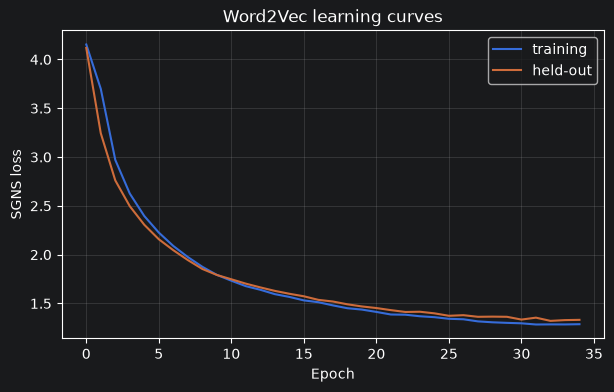

In [20]:
def train_word2vec(
    train_c, train_o, val_c, val_o, embedding_dim=30, num_negatives=5,
    epochs=35, batch_size=256, learning_rate=1.5, seed=42
):
    local_rng = np.random.default_rng(seed)
    model = SGNS(len(vocab), embedding_dim, local_rng)
    history = {'train': [], 'val': []}
    fixed_val_negatives = sample_negatives(len(val_c), num_negatives, val_o, local_rng)

    for epoch in range(epochs):
        permutation = local_rng.permutation(len(train_c))
        batch_losses = []
        for start in range(0, len(permutation), batch_size):
            idx = permutation[start:start + batch_size]
            c_batch, o_batch = train_c[idx], train_o[idx]
            negatives = sample_negatives(len(idx), num_negatives, o_batch, local_rng)
            batch_losses.append(model.step(c_batch, o_batch, negatives, learning_rate))

        train_loss = float(np.mean(batch_losses))
        val_loss = float(model.loss(val_c, val_o, fixed_val_negatives))
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch + 1:02d}: train={train_loss:.4f}, val={val_loss:.4f}')

    return model, history

model, history = train_word2vec(
    train_centers, train_contexts, val_centers, val_contexts
)

plt.figure(figsize=(7, 4))
plt.plot(history['train'], label='training')
plt.plot(history['val'], label='held-out')
plt.xlabel('Epoch')
plt.ylabel('SGNS loss')
plt.title('Word2Vec learning curves')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Checkpoint 2

1. Did both curves decrease?
2. If training loss decreases while held-out loss rises, what is the likely interpretation?
3. Why does a low SGNS loss not prove that the embeddings encode factual knowledge?

**Your response:**  

1. Yes both of the curves decreased.
2. If the held-out loss was increasing it means that it's overfitting, most likely because it's memorizing the specific pairs in the training  data rather than learning the pattern.
3. A low SGNS loss, just means that the model is good at predicting words appearance to each other in the corpus. It cannot determine if Paris is the capital of France, as a true fact. Had it been trained on Paris is the capital of Italy, it would then connect those two together even though that is factually wrong.

## 6. Evaluate nearest neighbors and analogies

In [21]:
def normalized_embeddings(model):
    # Combining input and output embeddings often gives a useful representation.
    E = model.W_in + model.W_out
    return E / np.maximum(np.linalg.norm(E, axis=1, keepdims=True), 1e-12)

E = normalized_embeddings(model)

def nearest_neighbors(word, top_k=6, embeddings=E):
    query_id = word_to_id[word]
    scores = embeddings @ embeddings[query_id]
    ranking = np.argsort(-scores)
    return [(id_to_word[i], float(scores[i])) for i in ranking if i != query_id][:top_k]

for word in ['king', 'queen', 'paris', 'dog', 'doctor', 'fruit']:
    print(f'\n{word}:', nearest_neighbors(word))

def analogy(a, b, c, top_k=5, embeddings=E):
    # b - a + c; for example, king - man + woman -> queen
    query = embeddings[word_to_id[b]] - embeddings[word_to_id[a]] + embeddings[word_to_id[c]]
    query = query / max(np.linalg.norm(query), 1e-12)
    scores = embeddings @ query
    excluded = {word_to_id[a], word_to_id[b], word_to_id[c]}
    ranking = [i for i in np.argsort(-scores) if i not in excluded]
    return [(id_to_word[i], float(scores[i])) for i in ranking[:top_k]]

print('king - man + woman:', analogy('man', 'king', 'woman'))
print('paris - france + germany:', analogy('france', 'paris', 'germany'))


king: [('queen', 0.9338466855664521), ('wears', 0.9272499610282586), ('crown', 0.6369850242327924), ('rule', 0.5186147005944844), ('a', 0.5075212547712876), ('prince', 0.44120865307814444)]

queen: [('king', 0.9338466855664521), ('rule', 0.7609964660043235), ('wears', 0.7522514991123784), ('kingdom', 0.5421912479704013), ('and', 0.4381777450192579), ('prince', 0.43274215605342176)]

paris: [('beijing', 0.9994844526872229), ('berlin', 0.9991188324537548), ('tokyo', 0.9987617888861796), ('rome', 0.9984656613633713), ('madrid', 0.9983139827583546), ('the', 0.92970767931103)]

dog: [('cat', 0.9622522593971133), ('kitten', 0.8943610781723367), ('puppy', 0.8922492434868463), ('young', 0.8630564300895504), ('horse', 0.8194595078743112), ('is', 0.6864064814449299)]

doctor: [('teacher', 0.9751793976076633), ('teaches', 0.9576365428532909), ('treats', 0.9530217455540505), ('works', 0.9459056499699324), ('student', 0.9420307384142801), ('learns', 0.9407386697805257)]

fruit: [('small', 0.934119

### Task 4 - Quantitative intrinsic evaluation

Measure whether a related target appears among the top five neighbors. This metric is deliberately small and interpretable; it is not a standardized benchmark.

In [22]:
RELATED_PAIRS = [
    ('king', 'queen'), ('prince', 'princess'), ('dog', 'cat'),
    ('puppy', 'kitten'), ('paris', 'berlin'), ('france', 'germany'),
    ('doctor', 'teacher'), ('hospital', 'school'), ('apple', 'banana')
]

def related_at_k(model, pairs, k=5):
    embeddings = normalized_embeddings(model)
    hits = []
    for query, target in pairs:
        neighbors = [w for w, _ in nearest_neighbors(query, k, embeddings)]
        hits.append(target in neighbors)
        print(f'{query:>8s} -> {target:<10s} | {neighbors} | hit={hits[-1]}')
    return float(np.mean(hits))

score = related_at_k(model, RELATED_PAIRS, k=5)
print(f'\nRelated@5 = {score:.3f}')

    king -> queen      | ['queen', 'wears', 'crown', 'rule', 'a'] | hit=True
  prince -> princess   | ['princess', 'and', 'grape', 'live', 'apple'] | hit=True
     dog -> cat        | ['cat', 'kitten', 'puppy', 'young', 'horse'] | hit=True
   puppy -> kitten     | ['kitten', 'dog', 'cat', 'young', 'is'] | hit=True
   paris -> berlin     | ['beijing', 'berlin', 'tokyo', 'rome', 'madrid'] | hit=True
  france -> germany    | ['japan', 'italy', 'china', 'germany', 'spain'] | hit=True
  doctor -> teacher    | ['teacher', 'teaches', 'treats', 'works', 'student'] | hit=True
hospital -> school     | ['school', 'learns', 'teacher', 'student', 'doctor'] | hit=True
   apple -> banana     | ['red', 'yellow', 'grape', 'orange', 'banana'] | hit=True

Related@5 = 1.000


## 7. Visualize selected embeddings

PCA is a projection: distances in two dimensions may distort relationships in the full embedding space.

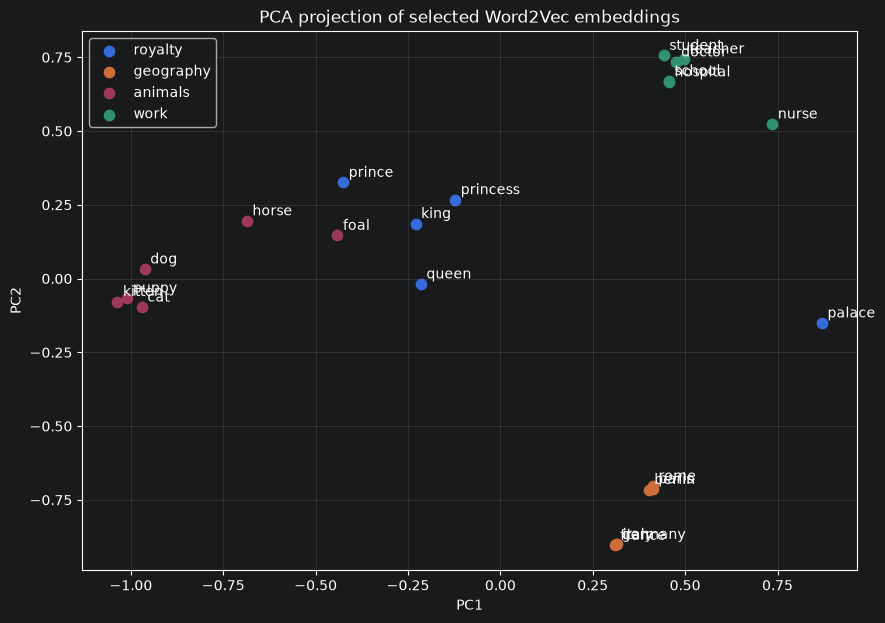

In [23]:
groups = {
    'royalty': ['king', 'queen', 'prince', 'princess', 'palace'],
    'geography': ['paris', 'france', 'berlin', 'germany', 'rome', 'italy'],
    'animals': ['dog', 'puppy', 'cat', 'kitten', 'horse', 'foal'],
    'work': ['doctor', 'nurse', 'hospital', 'teacher', 'student', 'school'],
}
selected = [word for words in groups.values() for word in words]
selected_ids = [word_to_id[w] for w in selected]
points = PCA(n_components=2).fit_transform(E[selected_ids])

plt.figure(figsize=(10, 7))
offset = 0
for label, words in groups.items():
    block = points[offset:offset + len(words)]
    plt.scatter(block[:, 0], block[:, 1], label=label, s=55)
    for word, (x, y) in zip(words, block):
        plt.annotate(word, (x, y), xytext=(4, 4), textcoords='offset points')
    offset += len(words)
plt.title('PCA projection of selected Word2Vec embeddings')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. Controlled experiment: context-window size

Train two otherwise identical models with window sizes 1 and 3. Record held-out loss, Related@5, qualitative neighbor differences, and runtime.

In [24]:
experiment_results = []
for window in [1, 3]:
    exp_c, exp_o = build_skipgram_pairs(encoded_sentences, window_size=window)
    exp_order = np.random.default_rng(RANDOM_STATE).permutation(len(exp_c))
    exp_split = int(0.90 * len(exp_order))
    tr, va = exp_order[:exp_split], exp_order[exp_split:]
    exp_model, exp_history = train_word2vec(
        exp_c[tr], exp_o[tr], exp_c[va], exp_o[va],
        epochs=25, seed=RANDOM_STATE
    )
    exp_score = related_at_k(exp_model, RELATED_PAIRS, k=5)
    experiment_results.append({
        'window': window,
        'pairs': len(exp_c),
        'final_val_loss': exp_history['val'][-1],
        'related_at_5': exp_score,
    })

experiment_results

Epoch 01: train=4.1584, val=4.1571
Epoch 05: train=2.6808, val=2.6021
Epoch 10: train=1.8378, val=1.8485
Epoch 15: train=1.4314, val=1.4532
Epoch 20: train=1.2239, val=1.2558
Epoch 25: train=1.1204, val=1.1322
    king -> queen      | ['and', 'prince', 'puppy', 'boy', 'wears'] | hit=False
  prince -> princess   | ['puppy', 'grape', 'apple', 'boy', 'purple'] | hit=False
     dog -> cat        | ['woman', 'cat', 'young', 'yellow', 'man'] | hit=True
   puppy -> kitten     | ['prince', 'grape', 'apple', 'and', 'purple'] | hit=False
   paris -> berlin     | ['berlin', 'rome', 'beijing', 'madrid', 'tokyo'] | hit=True
  france -> germany    | ['china', 'italy', 'germany', 'japan', 'spain'] | hit=True
  doctor -> teacher    | ['teacher', 'works', 'nurse', 'treats', 'teaches'] | hit=True
hospital -> school     | ['school', 'a', 'patient', 'loyal', 'student'] | hit=True
   apple -> banana     | ['grape', 'red', 'puppy', 'prince', 'purple'] | hit=False
Epoch 01: train=4.1427, val=4.0289
Epoch 05:

[{'window': 1,
  'pairs': 8160,
  'final_val_loss': 1.1321577576944568,
  'related_at_5': 0.5555555555555556},
 {'window': 3,
  'pairs': 18480,
  'final_val_loss': 1.4505709249681566,
  'related_at_5': 1.0}]

### Task 5 - Interpret the experiment

Report which window performed better under each metric. Explain why the result may differ between local syntactic relationships and broader semantic or topical relationships. Do not claim that one window is universally superior.

**Your response:**  

Window 1 had the lower `final_val_loss`, but Window 3 had the better `related_at_5` score. With the smaller window 1, since loss is measure the prediction accuracy of the immediate neighbors, it will get a lower loss since there are fewer things to predict. With a bigger window 3, broader semantic and topical relationships will be easier to match, since we got a bigger window allowing the model to see more of the sentence.

## 9. Final analysis questions

Answer each in 3-5 sentences.

1. **Two embedding tables:** Why does SGNS learn both `W_in` and `W_out`? Why might we use `W_in`, `W_out`, or their sum at inference time?
2. **Polysemy:** This implementation assigns one vector to each word type. What happens to a word such as `bank` with multiple meanings?
3. **Bias:** How can social bias enter Word2Vec embeddings? Propose one diagnostic.
4. **Evaluation:** Why are nearest-neighbor examples and a two-dimensional PCA plot insufficient evidence of model quality?
5. **Extension:** Propose one experiment on a larger natural corpus, including a hypothesis, independent variable, dependent metric, and controlled variables.

**Your responses:**  

1. Each word have two roles. At one point it is predicting, meaning it's the center word, and at some point it is being predicted, meaning it's the context word. By splitting them up in two vectors, we try to prevent the model from getting confused by comparing a word to itself. `W_in` could be used on its own, because it tends to give more semantically richer presentation. `W_out` on its own, will show how often a word gets predicted. By summing them up at inference time we get a more useful representation than either one would have provided alone.
2. Since a word like `bank` is static, our model will have a hard time knowing if it refers to a `river bank` or a `financial bank`. Therefore, it will depend on the data it was trained and lean more torwards that meaning.
3. Bias can enter when a model is trained on a text that in itself shows a social bias. Say jobs mentioned alongside a gender. It might be trained on only men doing construction and IT, while only women are teacher and nurses. Apart from the fact that this text represented it that way, it is in its entirety not factual. A diagnostic would be to take the cosine similarity between man and woman, against the occupations, to see if there is a gender that sits closer to certain jobs. This would have to be done over multiple pairs as a single one could just be by chance.
4. Nearest-neighbor examples are just looking at some cherry picked good cases, meaning on a broader space it might not perform as well. By turning it into a 2-dimensional space, you lose some value you get from the depth. Just because two words look close together, doesn't mean they actually are. This is just the flattening making look like belong right next to each other.
5. We can use Wikipedia as an example for a large corpus. **Hypothesis:** Embeddings trained on this larger natural language corpus will perform better on word relathionships tasks, because this real text provides us with a far more varied context to differentiate similair words. **Independent Variable:** The Wikipedia dump and our synthetic training corpus. **Dependent Metric:** Will be using `related_at_5` by using the `related_at_k` function already built into this lab. **Controlled Variables:** For this we will be using embedding dimensions, window size, number of negative samples, number of epochs, learning rate, random seed, and keep evaluation sets identical so only `k` changes.

## AI assistance disclosure

AI was used to help debug a scipy compatability error.

## Submission checklist

- [x] All implementation cells run from top to bottom.
- [x] Gradient check passes.
- [x] Learning-curve plot is included.
- [x] Nearest-neighbor and analogy outputs are shown.
- [x] Window-size experiment is completed and interpreted.
- [x] Five final analysis questions are answered.
- [x] Meaningful AI assistance is disclosed.